# Simulaciones del proceso de contacto con pesos sobre el grafo completo

Este notebook implementa el **método directo de Gillespie** para el proceso de contacto con pesos sobre el grafo completo

$$
G=(V,E),\qquad V=\{1,\ldots,n\},
$$

siguiendo la notación y el pseudocódigo empleados en la Sección 5.4 del trabajo de grado.

Se conservan únicamente las simulaciones utilizadas en las figuras del capítulo de simulaciones de la sección 6.1:

1. comportamiento con distribuciones de **colas livianas**, para pesos Gamma y normales truncados;
2. comportamiento con distribuciones de **colas pesadas**, usando pesos Pareto y Cauchy;
3. efecto del tamaño del grafo para
   $$
   n\in\{5,100,1000,10000\}.
   $$

El algoritmo de Gillespie se programa **una sola vez** y se reutiliza en todas las figuras. Para acelerar la selección ponderada de un vértice sano se utiliza internamente un **Fenwick tree**. Esta estructura **no modifica el algoritmo**: solamente implementa de manera más eficiente el Paso 3b del pseudocódigo.

## 1. El proceso de contacto con pesos

Condicionamos en una realización de la sucesión de pesos

$$
\mathbf w=(w_i)_{i \ge 0}.
$$

El proceso inicia con todos los vértices infectados:
$$
\eta_0^V=V.
$$

En el tiempo $t$, definimos
$$
I_t=\{i\in V:\eta_t^V(i)=1\},
\qquad
S_t=\{i\in V:\eta_t^V(i)=0\}.
$$

Además,
$$
W_{I_t}=\sum_{i\in I_t}w_i,
\qquad
W_{S_t}=\sum_{j\in S_t}w_j.
$$

Cada vértice infectado se recupera a tasa $1$, de modo que
$$
\lambda_{\mathrm{rec}}=|I_t|.
$$

Si $j\in S_t$, su tasa de infección es
$$
\frac{\lambda}{n}w_j\sum_{i\in I_t}w_i
=
\frac{\lambda}{n}w_jW_{I_t}.
$$
Por tanto, la tasa total de infección es
$$
\lambda_{\mathrm{inf}}
=
\sum_{j\in S_t}\frac{\lambda}{n}w_jW_{I_t}
=
\frac{\lambda}{n}W_{I_t}W_{S_t}.
$$

La tasa total del proceso es
$$
\Lambda
=
\lambda_{\mathrm{rec}}+\lambda_{\mathrm{inf}}.
$$

Cuando $\mathbb E(w_1^2)<\infty$, el parámetro crítico teórico es
$$
\lambda_c=\frac{1}{\mathbb E(w_1^2)}.
$$

## 2. Correspondencia con el pseudocódigo de Gillespie

La simulación sigue los mismos pasos del pseudocódigo presentado en sección 5.4:

| Pseudocódigo | Implementación |
|---|---|
| Paso 0a | Inicializar $t=0$, $I_0=V$, $S_0=\varnothing$, $W_{I_0}=\sum_iw_i$, $W_{S_0}=0$ |
| Paso 0b | $\lambda_{\mathrm{rec}}=|I_t|$, $\lambda_{\mathrm{inf}}=(\lambda/n)W_{I_t}W_{S_t}$, $\Lambda=\lambda_{\mathrm{rec}}+\lambda_{\mathrm{inf}}$ |
| Paso 1 | Generar $U_1\sim\mathrm{Unif}(0,1)$ y $\tau=-\log U_1/\Lambda$ |
| Paso 2 | Generar $U_2\sim\mathrm{Unif}(0,\Lambda)$ y determinar el tipo de evento |
| Paso 3a | Si hay recuperación, elegir $i\in I_t$ uniformemente |
| Paso 3b | Si hay infección, elegir $j\in S_t$ con probabilidad $w_j/W_{S_t}$ |
| Paso 4 | Avanzar el tiempo: $t\leftarrow t+\tau$ |
| Paso 5 | Actualizar incrementalmente $W_{I_t}$ y $W_{S_t}$ |
| Paso 6 | Repetir hasta extinción o hasta $T_{\max}$ |

La única diferencia computacional es **cómo se realiza la selección del Paso 3b**. El pseudocódigo especifica la distribución del vértice sano que debe elegirse; el Fenwick tree es únicamente una estructura de datos para efectuar esa misma selección de manera más rápida.

## 3. Fenwick tree: qué hace y por qué la utilizamos

Cuando ocurre una infección, el pseudocódigo exige seleccionar $j\in S_t$ según

$$
\mathbb P\bigl(j \in S_t\text{ se infecte}\mid\text{ocurre una infección}\bigr)
=
\frac{w_j}{W_{S_t}}.
$$

### Selección directa

Una implementación directa construye el vector de probabilidades

$$
\left(\frac{w_j}{W_{S_t}}\right)_{j\in S_t}
$$

y utiliza una elección ponderada. Es correcta, pero en cada infección puede requerir recorrer una parte importante del conjunto $S_t$, por lo que su costo puede ser alto si $n$ es muy grande.

### Selección mediante Fenwick tree

Definimos

$$
x_j(t)=w_j\,\mathbf 1_{\{j\in S_t\}}.
$$
El Fenwick tree mantiene las sumas acumuladas
$$
F_t(k)=\sum_{j=1}^{k}x_j(t).
$$

Como

$$
F_t(n)=W_{S_t},
$$

generamos

$$
U\sim\operatorname{Unif}(0,W_{S_t})
$$

y elegimos el menor índice $j$ tal que

$$
F_t(j)>U.
$$

Es decir, el menor $j$ tal que

$$F_t(j-1)\le U < F_t(j)$$

El intervalo correspondiente al vértice $j$ tiene longitud exactamente $w_j$. En consecuencia,

$$
\mathbb P(j\text{ sea elegido})
=
\frac{w_j}{W_{S_t}},
$$

que es **exactamente la probabilidad del Paso 3b del pseudocódigo**.

Por ello, el pseudocódigo y la implementación con Fenwick tree generan la **misma selección probabilística**. La diferencia es únicamente de eficiencia.

Esta mejora es especialmente útil para $n=1000$ y $n=10000$, donde pueden ocurrir muchos eventos antes de terminar la simulación.

In [ ]:
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 42
MAX_EVENTOS = 2_000_000

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
    "lines.linewidth": 2.0,
})

## 4. Estructura Fenwick tree

El árbol almacena, en cada instante, el peso
$$
x_j(t)=
\begin{cases}
w_j, & j\in S_t,\\
0, & j\in I_t.
\end{cases}
$$

Inicialmente $S_0=\varnothing$, por lo que todos los valores almacenados son cero. Si un vértice se recupera se añade su peso al árbol; si se infecta se elimina su peso. Así, la suma total representada por el árbol coincide siempre con $W_{S_t}$.

In [ ]:
class FenwickTree:
    """Fenwick tree para actualizar los pesos."""

    def __init__(self, n):
        self.n = int(n)
        self.tree = np.zeros(self.n + 1, dtype=float)

    def update(self, index, delta):
        i = int(index) + 1
        while i <= self.n:
            self.tree[i] += delta
            i += i & -i

    def sample(self, target):
        """
        Devuelve el menor índice j cuya suma acumulada es > target.
        Se requiere 0 <= target < suma total almacenada.
        """
        idx = 0
        bit = 1 << (self.n.bit_length() - 1)

        while bit:
            siguiente = idx + bit
            if siguiente <= self.n and self.tree[siguiente] <= target:
                target -= self.tree[siguiente]
                idx = siguiente
            bit >>= 1

        return min(idx, self.n - 1)

## 5. Implementación del método directo de Gillespie

La siguiente función se utiliza en todas las simulaciones. Para conservar la correspondencia con el pseudocódigo se mantienen explícitamente las cantidades
$$
\lambda_{\mathrm{rec}},\quad
\lambda_{\mathrm{inf}},\quad
\Lambda,\quad U_1,\quad U_2,\quad \tau.
$$

La lista `I_t` permite elegir una recuperación uniformemente. El vector `posicion` permite actualizar esa lista sin buscar un vértice en todo el conjunto. El Fenwick tree se utiliza **solamente** en el Paso 3b.

Si el próximo evento está programado después de $T_{\max}$, dicho evento no ocurre dentro del horizonte observado; se registra el estado vigente en $T_{\max}$ y se termina la trayectoria.

In [ ]:
def simular_proceso_contacto(n, w, lambda_, T_max, rng, max_eventos=MAX_EVENTOS):
    """
    Método directo de Gillespie para el proceso de contacto con pesos en G(E,V).

    Estado inicial: eta_0^V = V (todos los vértices infectados).
    Retorna los tiempos registrados y la fracción |I_t|/n.
    """
    w = np.asarray(w, dtype=float)

    if len(w) != n:
        raise ValueError("El vector de pesos debe tener longitud n.")
    if np.any(w < 0):
        raise ValueError("Los pesos deben ser no negativos.")

    # --------------------------------------------------------
    # PASO 0a. Inicialización
    # --------------------------------------------------------
    t = 0.0
    I_t = list(range(n))                   # I_0 = V
    posicion = np.arange(n, dtype=int)     # -1 significará susceptible

    arbol_S = FenwickTree(n)               # S_0 = vacío
    W_It = float(np.sum(w))
    W_St = 0.0

    tiempos = [0.0]
    densidades = [1.0]

    # --------------------------------------------------------
    # PASO 6. Repetición
    # --------------------------------------------------------
    for _ in range(max_eventos):
        numero_infectados = len(I_t)

        if numero_infectados == 0 or t >= T_max:
            break

        # ----------------------------------------------------
        # PASO 0b. Cálculo de tasas
        # ----------------------------------------------------
        lambda_rec = float(numero_infectados)
        lambda_inf = (lambda_ / n) * W_It * W_St
        Lambda = lambda_rec + lambda_inf

        if Lambda <= 0.0:
            break

        # ----------------------------------------------------
        # PASO 1. Tiempo hasta el siguiente evento
        # ----------------------------------------------------
        U1 = max(rng.random(), np.finfo(float).tiny)
        tau = -math.log(U1) / Lambda
        t_nuevo = t + tau

        if t_nuevo > T_max:
            tiempos.append(T_max)
            densidades.append(numero_infectados / n)
            break

        # ----------------------------------------------------
        # PASO 2. Tipo de evento
        # ----------------------------------------------------
        U2 = rng.random() * Lambda

        if U2 <= lambda_rec:
            # ------------------------------------------------
            # PASO 3a. Recuperación: i en I_t uniformemente
            # ------------------------------------------------
            k = int(rng.integers(numero_infectados))
            i = I_t[k]

            ultimo = I_t[-1]
            I_t[k] = ultimo
            posicion[ultimo] = k
            I_t.pop()
            posicion[i] = -1

            wi = float(w[i])

            # PASO 5. Actualización incremental
            W_It -= wi
            W_St += wi
            arbol_S.update(i, wi)           # i pasa a S_t

        else:
            # ------------------------------------------------
            # PASO 3b. Infección: P(j)=w_j/W_St
            # ------------------------------------------------
            if W_St <= 0.0:
                continue

            U_ponderado = rng.random() * W_St
            j = arbol_S.sample(U_ponderado)
            wj = float(w[j])

            if wj <= 0.0 or posicion[j] != -1:
                continue

            arbol_S.update(j, -wj)          # j sale de S_t
            posicion[j] = len(I_t)
            I_t.append(j)                   # j entra a I_t

            # PASO 5. Actualización incremental
            W_St -= wj
            W_It += wj

        # ----------------------------------------------------
        # PASO 4. Avanzar el tiempo y registrar
        # ----------------------------------------------------
        t = t_nuevo
        tiempos.append(t)
        densidades.append(len(I_t) / n)

    else:
        warnings.warn(
            "Se alcanzó MAX_EVENTOS antes de terminar la trayectoria. "
            "Aumente MAX_EVENTOS si es necesario."
        )

    return np.asarray(tiempos), np.asarray(densidades)

## 6. Distribuciones de pesos y parámetros críticos

Las distribuciones se definen una sola vez. Dentro de cada panel se usa la misma realización de $\mathbf w$ al comparar distintos valores de $\lambda$, de modo que el cambio observado corresponda al régimen del proceso y no a una nueva realización de los pesos.

In [ ]:
# Distribución Gamma
def pesos_gamma(n, k=2.0, theta=1.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.gamma(shape=k, scale=theta, size=n)


# Distribución Normal truncada
def pesos_normal_truncada(n, mu=2.0, sigma=1.0, rng=None):
    """W=max(X,0), con X~N(mu,sigma^2)."""
    rng = np.random.default_rng() if rng is None else rng
    X = rng.normal(loc=mu, scale=sigma, size=n)
    return np.maximum(X, 0.0)


# Distribución Pareto
def pesos_pareto(n, x_m=1.0, alpha=1.5, rng=None):
    """Pareto tipo I con escala x_m y parámetro alpha."""
    rng = np.random.default_rng() if rng is None else rng
    return x_m * (1.0 + rng.pareto(alpha, size=n))


# Distribución Cauchy
def pesos_cauchy_no_negativos(n, x0=2.0, gamma=1.0, rng=None):
    """W=|X|, X~Cauchy(x0,gamma), para obtener pesos no negativos."""
    rng = np.random.default_rng() if rng is None else rng
    U = rng.random(n)
    X = x0 + gamma * np.tan(np.pi * (U - 0.5))
    return np.abs(X)


def segundo_momento_gamma(k=2.0, theta=1.0):
    return k * (k + 1.0) * theta**2


def segundo_momento_normal_truncada(mu=2.0, sigma=1.0):
    """E[W^2] para W=max(X,0), X~N(mu,sigma^2)."""
    a = mu / sigma
    Phi = 0.5 * (1.0 + math.erf(a / math.sqrt(2.0)))
    phi = math.exp(-0.5 * a**2) / math.sqrt(2.0 * math.pi)
    return (mu**2 + sigma**2) * Phi + mu * sigma * phi

## 7. Gráficas


In [ ]:
def escenarios_regimenes(lambda_c, lambda_sub=0.10, lambda_super=0.25):
    return [
        (rf"Subcrítico: $\lambda={lambda_sub:.2f}$", lambda_sub, "--"),
        (rf"Crítico: $\lambda_c={lambda_c:.4f}$", lambda_c, "-"),
        (rf"Supercrítico: $\lambda={lambda_super:.2f}$", lambda_super, "-"),
    ]


def formatear_eje(ax, titulo, T_max):
    ax.set_title(titulo, pad=12)
    ax.set_xlabel(r"Tiempo $t$")
    ax.set_ylabel(r"Fracción de infectados $|I_t|/n$")
    ax.set_xlim(0, T_max)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.55)


def graficar_regimenes_en_eje(ax, n, w, lambda_c, T_max, titulo, seed_base,
                               lambda_sub=0.10, lambda_super=0.25):
    for k, (etiqueta, lambda_, estilo) in enumerate(
        escenarios_regimenes(lambda_c, lambda_sub, lambda_super)
    ):
        rng_sim = np.random.default_rng(seed_base + k)
        tiempos, densidades = simular_proceso_contacto(
            n=n, w=w, lambda_=lambda_, T_max=T_max, rng=rng_sim
        )
        ax.plot(tiempos, densidades, linestyle=estilo, label=etiqueta)

    formatear_eje(ax, titulo, T_max)


def graficar_lambdas_en_eje(ax, n, w, lambdas, T_max, titulo, seed_base):
    for k, lambda_ in enumerate(lambdas):
        rng_sim = np.random.default_rng(seed_base + k)
        tiempos, densidades = simular_proceso_contacto(
            n=n, w=w, lambda_=lambda_, T_max=T_max, rng=rng_sim
        )
        ax.plot(tiempos, densidades, label=rf"$\lambda={lambda_}$")

    formatear_eje(ax, titulo, T_max)


def leyenda_compartida(fig, ax_referencia, titulo, ncol):
    handles, labels = ax_referencia.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title=titulo,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=ncol,
        frameon=True,
        framealpha=0.97,
        borderpad=0.9,
        labelspacing=0.65,
        handlelength=3.0,
        fontsize=12,
        title_fontsize=13,
    )

# 8. Simulación 1 — Regímenes con pesos de colas livianas

Se considera $n=200$.

### 8.1. Pesos Gamma

$$
w_1\sim\Gamma(2,1).
$$

Como

$$
\mathbb E(w_1^2)=k(k+1)\theta^2=6,
$$

se tiene

$$
\lambda_c=\frac16\approx0.1667.
$$


### 8.2. Pesos normales truncados
$$
w_1=\max\{X,0\},
\qquad
X\sim N(2,1).
$$

Se calcula exactamente $\mathbb E(W^2)$ y luego
$$
\lambda_c=\frac{1}{\mathbb E(w_1^2)} \approx 0.2002.
$$

In [ ]:
n = 200
T_max = 50.0

# Gamma
GAMMA_K = 2.0
GAMMA_THETA = 1.0
EW2_gamma = segundo_momento_gamma(GAMMA_K, GAMMA_THETA)
lambda_c_gamma = 1.0 / EW2_gamma

rng_w = np.random.default_rng(SEMILLA)
w_gamma = pesos_gamma(n, GAMMA_K, GAMMA_THETA, rng_w)

# Normal truncada
NORMAL_MU = 2.0
NORMAL_SIGMA = 1.0
EW2_normal = segundo_momento_normal_truncada(NORMAL_MU, NORMAL_SIGMA)
lambda_c_normal = 1.0 / EW2_normal

rng_w = np.random.default_rng(SEMILLA + 100)
w_normal = pesos_normal_truncada(n, NORMAL_MU, NORMAL_SIGMA, rng_w)

print(f"Gamma: E[w_1²] = {EW2_gamma:.6f}, lambda_c = {lambda_c_gamma:.6f}")
print(f"Normal truncada: E[w_1²] = {EW2_normal:.6f}, lambda_c = {lambda_c_normal:.6f}")

Gamma: E[w_1²] = 6.000000, lambda_c = 0.166667
Normal truncada: E[w_1²] = 4.994231, lambda_c = 0.200231


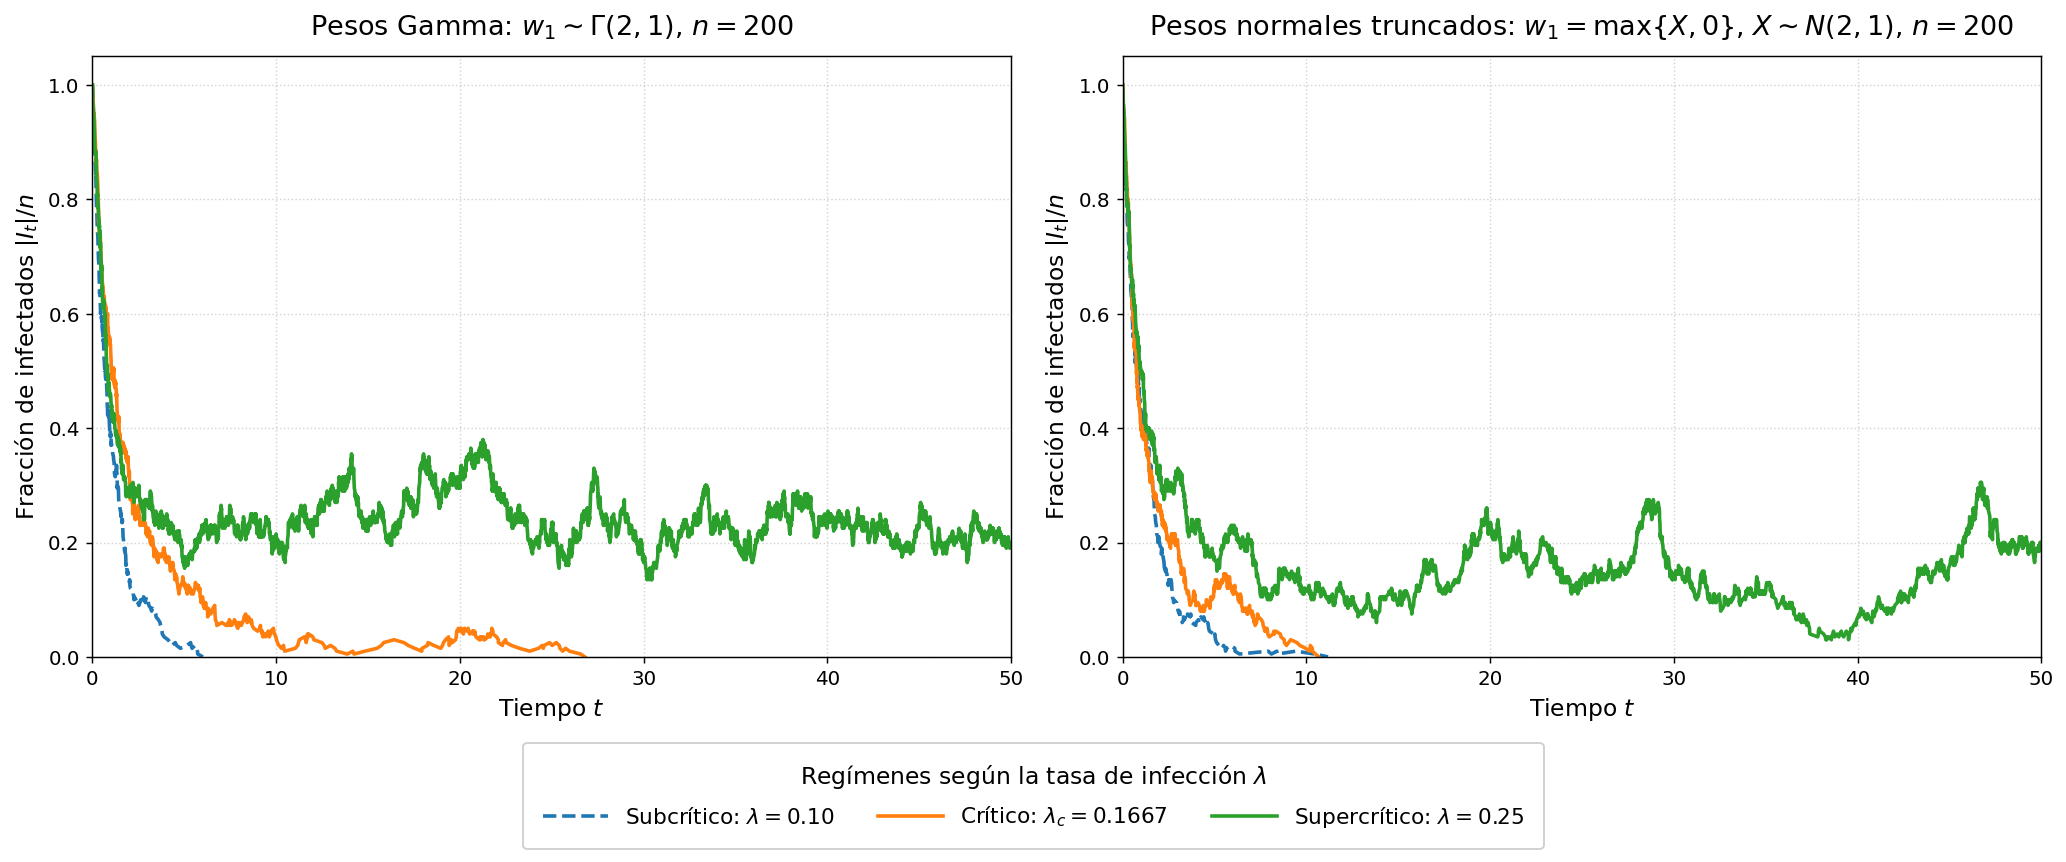

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.7))

graficar_regimenes_en_eje(
    axes[0], n, w_gamma, lambda_c_gamma, T_max,
    rf"Pesos Gamma: $w_1\sim\Gamma({GAMMA_K:g},{GAMMA_THETA:g})$, $n={n}$",
    seed_base=1_000,
)

graficar_regimenes_en_eje(
    axes[1], n, w_normal, lambda_c_normal, T_max,
    rf"Pesos normales truncados: $w_1=\max\{{X,0\}}$, $X\sim N({NORMAL_MU:g},{NORMAL_SIGMA:g})$, $n={n}$",
    seed_base=2_000,
)

leyenda_compartida(
    fig, axes[0],
    titulo=r"Regímenes según la tasa de infección $\lambda$",
    ncol=3,
)

fig.tight_layout(rect=(0, 0.14, 1, 1))
plt.show()

# 9. Simulación 2 — Pesos de colas pesadas

Se considera $n=200$ y

$$
\lambda\in\{0.1,0.2,0.5,1.0\}.
$$

Para
$$
w_1\sim\operatorname{Pareto}(1,1.5),
$$

se tiene $\mathbb E(w_1^2)=\infty$.

Para los pesos de tipo Cauchy se toma
$$
w_1\sim\operatorname{Cauchy}(2,1),
$$

de modo que los pesos son no negativos. También en este caso
$\mathbb E(w_1^2)=\infty$.

In [ ]:
n = 200
T_max = 50.0
lambdas_pesadas = [0.1, 0.2, 0.5, 1.0]

PARETO_XM = 1.0
PARETO_ALPHA = 1.5
rng_w = np.random.default_rng(SEMILLA + 200)
w_pareto = pesos_pareto(n, PARETO_XM, PARETO_ALPHA, rng_w)

CAUCHY_X0 = 2.0
CAUCHY_GAMMA = 1.0
rng_w = np.random.default_rng(SEMILLA + 300)
w_cauchy = pesos_cauchy_no_negativos(n, CAUCHY_X0, CAUCHY_GAMMA, rng_w)

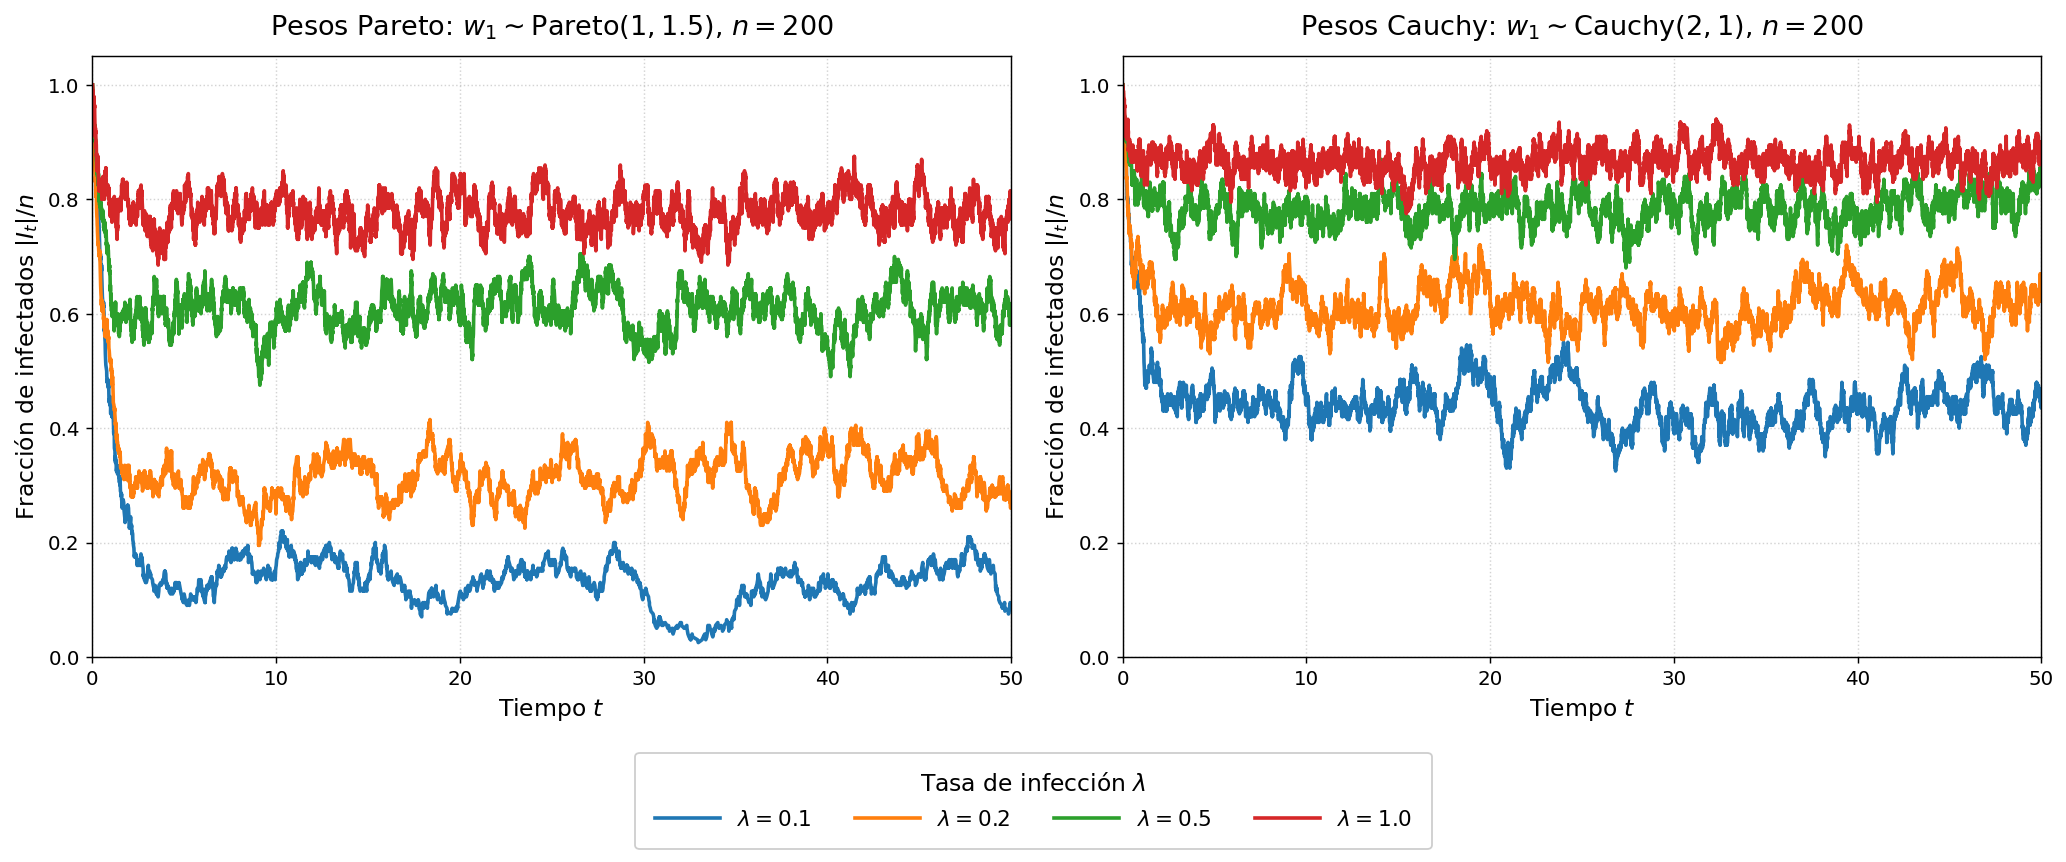

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.7))

graficar_lambdas_en_eje(
    axes[0], n, w_pareto, lambdas_pesadas, T_max,
    rf"Pesos Pareto: $w_1\sim\text{{Pareto}}({PARETO_XM:g},{PARETO_ALPHA:g})$, $n={n}$",
    seed_base=3_000,
)

graficar_lambdas_en_eje(
    axes[1], n, w_cauchy, lambdas_pesadas, T_max,
    rf"Pesos Cauchy: $w_1\sim\text{{Cauchy}}({CAUCHY_X0:g},{CAUCHY_GAMMA:g})$, $n={n}$",
    seed_base=4_000,
)

leyenda_compartida(
    fig, axes[0],
    titulo=r"Tasa de infección $\lambda$",
    ncol=4,
)

fig.tight_layout(rect=(0, 0.14, 1, 1))
plt.show()

# 10. Simulación 3 — Efecto del tamaño del grafo

Se mantienen los pesos

$$
w_1\sim\Gamma(2,1),
\qquad
\lambda_c=\frac16,
$$

y se consideran

$$
n\in\{5,100,1000,10000\}.
$$

En cada panel se muestran los tres regímenes

$$
\lambda=0.10\quad\text{(subcrítico)},
\qquad
\lambda=\lambda_c=0.1667\quad\text{(crítico)},
\qquad
\lambda=0.25\quad\text{(supercrítico)}.
$$

Aquí la optimización mediante Fenwick tree resulta especialmente útil, porque la selección ponderada continúa teniendo costo $O(\log n)$ incluso para $n=10000$.

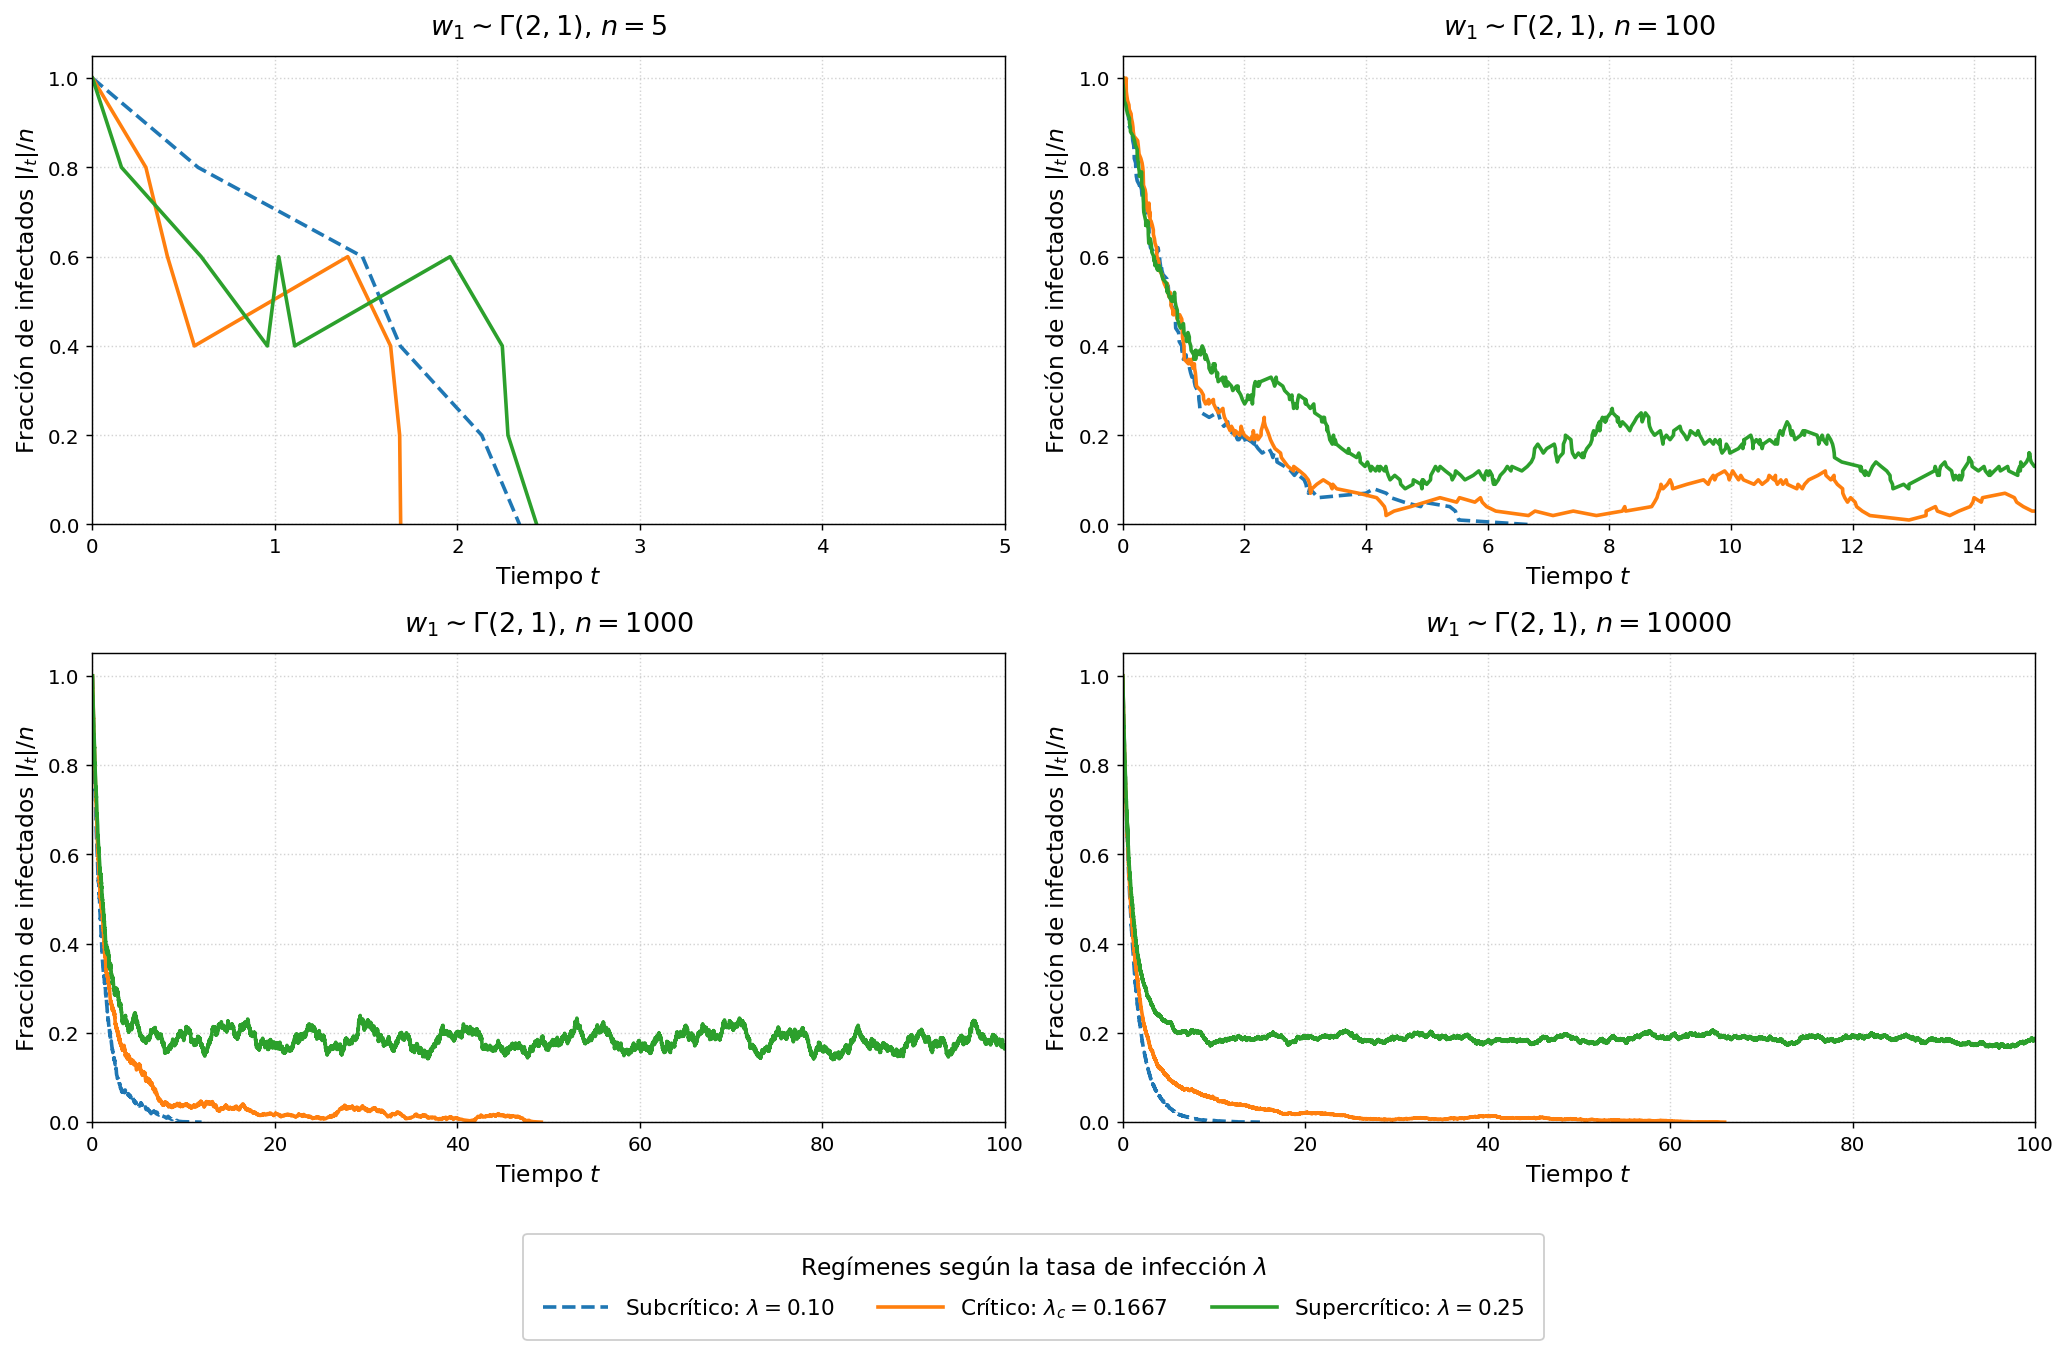

In [ ]:
n_values = [5, 100, 1000, 10000]

T_max_por_n = {
    5: 5.0,
    100: 15.0,
    1000: 100.0,
    10000: 100.0,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10.5))

for panel, (ax, n_actual) in enumerate(zip(axes.flat, n_values)):
    rng_w = np.random.default_rng(SEMILLA + 500 + panel)
    w = pesos_gamma(n_actual, GAMMA_K, GAMMA_THETA, rng_w)

    graficar_regimenes_en_eje(
        ax, n_actual, w, lambda_c_gamma, T_max_por_n[n_actual],
        rf"$w_1\sim\Gamma({GAMMA_K:g},{GAMMA_THETA:g})$, $n={n_actual}$",
        seed_base=5_000 + 10 * panel,
    )

leyenda_compartida(
    fig, axes.flat[0],
    titulo=r"Regímenes según la tasa de infección $\lambda$",
    ncol=3,
)

fig.tight_layout(rect=(0, 0.11, 1, 1))
plt.show()

## 11. Reproducibilidad

Las semillas utilizadas en las simulaciones se fijan explícitamente en el notebook. Las figuras pueden reproducirse ejecutando las celdas en orden desde el inicio. Las dependencias principales son `numpy` y `matplotlib`.
